# Simulation energy histograms

Load the simulation parquet, apply an astrophysical flux weight, and plot:
1. `MCPrimaryEnergy` (true neutrino energy)
2. `reco_energy`

Weight: `fluxless_weight × φ₀ × 10⁻¹⁸ × (E / 10⁵)^{−γ}`  with φ₀ = 2.12, γ = 2.87

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
PARQUET_PATH = (
    "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/datasets/"
    "flavor_globalfit/hese/combined_with_bdt/"
    "IC86_pass2_SnowStorm_v2_FTP_Baseline_Combined_v7-v1_fluxlessweight/"
    "mcd-simpletopology_flux-hese_feat-11features_plus_rloglmilli_econf_evtgen/"
    "dataset_IC86_pass2_SnowStorm_v2_FTP_Baseline_Combined_v7-v1_fluxlessweight.parquet"
)

# PARQUET_PATH = (
#     "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/datasets/flavor_globalfit/hese/combined/IC86_pass2_SnowStorm_v2_FTP_Baseline_hdf-v7_noMuon_fluxlessweight/dataset_IC86_pass2_SnowStorm_v2_FTP_Baseline_hdf-v7_noMuon_fluxlessweight.parquet"
# )

PHI_0 = 2.12   # normalisation [10^-18 GeV^-1 cm^-2 s^-1 sr^-1]
GAMMA = 2.87   # spectral index

In [17]:
df = pd.read_parquet(PARQUET_PATH)
print(f"Events: {len(df):,}")

flux        = 0.5 * PHI_0 * 1e-18 * (df["MCPrimaryEnergy"] / 1e5) ** (-GAMMA)
weight      = (df["fluxless_weight"] * flux).fillna(0)
rate_per_yr = weight.sum() * 365.25 * 24 * 3600 

print(f"Total rate: {weight.sum():.3e} s⁻¹  →  {rate_per_yr:.2f} yr⁻¹")
print(f"Lowest MCPrimaryEnergy: {df['MCPrimaryEnergy'].min():.2e} GeV")
print(f"Lowest reco_energy:     {df['reco_energy'].min():.2e} GeV")

Events: 698,848
Total rate: 3.015e-07 s⁻¹  →  9.52 yr⁻¹
Lowest MCPrimaryEnergy: 1.34e+04 GeV
Lowest reco_energy:     1.00e+03 GeV


## Histograms

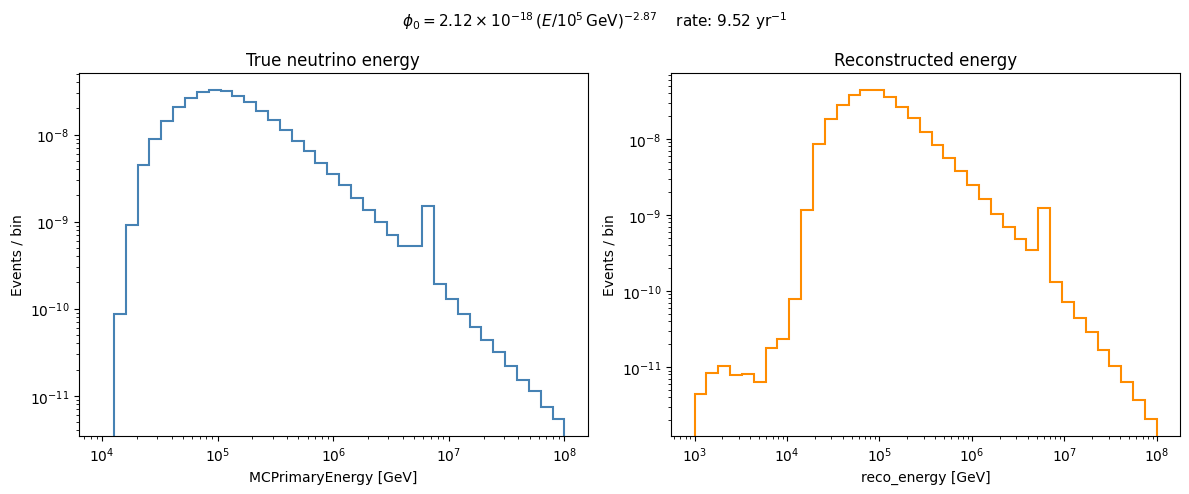

In [19]:
bins_true = np.logspace(np.log10(1e4), np.log10(1e8), 40)
bins_reco = np.logspace(np.log10(1e3), np.log10(1e8), 40)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df["MCPrimaryEnergy"], bins=bins_true, weights=weight,
             histtype="step", color="steelblue", linewidth=1.5)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("MCPrimaryEnergy [GeV]")
axes[0].set_ylabel("Events / bin")
axes[0].set_title("True neutrino energy")

axes[1].hist(df["reco_energy"], bins=bins_reco, weights=weight,
             histtype="step", color="darkorange", linewidth=1.5)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("reco_energy [GeV]")
axes[1].set_ylabel("Events / bin")
axes[1].set_title("Reconstructed energy")

fig.suptitle(
    rf"$\phi_0={PHI_0}\times10^{{-18}}\,(E/10^5\,\mathrm{{GeV}})^{{-{GAMMA}}}$"
    rf"    rate: {rate_per_yr:.2f} yr$^{{-1}}$",
    fontsize=11,
)
fig.tight_layout()
plt.savefig("sim_energy_histograms.pdf", bbox_inches="tight")
plt.show()